In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [3]:
df=pd.read_csv('ride_fare_clean.csv')

In [4]:
df.head()

,is_weekend,is_peak_hour,trip_distance_km,passenger_count,ride_type,vehicle_type,weather,traffic_level,surge_multiplier,fare
0,0,0,11.902094,1,UberX,Hatchback,Clear,Medium,1.0,23.53
1,1,1,22.562023,1,LyftPlus,SUV,Clear,Medium,2.5,55.94
2,1,0,10.355448,3,UberX,Sedan,Clear,Medium,2.0,31.34
3,1,1,22.162918,1,UberX,SUV,Cloudy,Low,1.0,34.82
4,1,0,22.825534,1,UberX,Van,Clear,Medium,1.0,38.85


In [5]:
X=df.drop('fare',axis=1)

In [6]:
X

,is_weekend,is_peak_hour,trip_distance_km,passenger_count,ride_type,vehicle_type,weather,traffic_level,surge_multiplier
0,0,0,11.902094,1,UberX,Hatchback,Clear,Medium,1.0
1,1,1,22.562023,1,LyftPlus,SUV,Clear,Medium,2.5
2,1,0,10.355448,3,UberX,Sedan,Clear,Medium,2.0
3,1,1,22.162918,1,UberX,SUV,Cloudy,Low,1.0
4,1,0,22.825534,1,UberX,Van,Clear,Medium,1.0
...,...,...,...,...,...,...,...,...,...
4995,1,1,14.934729,1,UberX,Sedan,Clear,Medium,2.0
4996,0,0,22.466492,1,UberX,Sedan,Clear,Low,1.5
4997,0,1,17.604705,5,Lyft,Hatchback,Clear,Medium,1.0
4998,0,0,3.183313,3,UberXL,SUV,Rainy,Medium,1.0


In [7]:
y=df['fare']

In [8]:
y

0       23.53
1       55.94
2       31.34
3       34.82
4       38.85
        ...  
4995    39.46
4996    45.07
4997    33.84
4998    14.10
4999    27.60
Name: fare, Length: 5000, dtype: float64

In [9]:

print("Categories in 'ride_type' variable: ",end=" ")
print(df['ride_type'].unique())

print("Categories in 'vehicle_type' variable: ",end=" ")
print(df['vehicle_type'].unique())

print("Categories in 'weather' variable: ",end=" ")
print(df['weather'].unique())

print("Categories in 'traffic_level' variable: ",end=" ")
print(df['traffic_level'].unique())

Categories in 'ride_type' variable:  <StringArray>
['UberX', 'LyftPlus', 'UberXL', 'Standard', 'Lyft']
Length: 5, dtype: str
Categories in 'vehicle_type' variable:  <StringArray>
['Hatchback', 'SUV', 'Sedan', 'Van']
Length: 4, dtype: str
Categories in 'weather' variable:  <StringArray>
['Clear', 'Cloudy', 'Rainy', 'Snowy']
Length: 4, dtype: str
Categories in 'traffic_level' variable:  <StringArray>
['Medium', 'Low', 'High', 'Very Heavy']
Length: 4, dtype: str


In [10]:
num_features = X.select_dtypes(exclude="string").columns
cat_features = X.select_dtypes(include="string").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features),        
    ]
)

In [13]:
X = preprocessor.fit_transform(X)

In [16]:
X.shape

(5000, 22)

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((4000, 22), (1000, 22))

In [17]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [18]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 1.5364
- Mean Absolute Error: 1.2239
- R2 Score: 0.9801
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.6110
- Mean Absolute Error: 1.2932
- R2 Score: 0.9761


Lasso
Model performance for Training set
- Root Mean Squared Error: 2.8838
- Mean Absolute Error: 2.3118
- R2 Score: 0.9300
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 2.8060
- Mean Absolute Error: 2.2831
- R2 Score: 0.9276


Ridge
Model performance for Training set
- Root Mean Squared Error: 1.5364
- Mean Absolute Error: 1.2240
- R2 Score: 0.9801
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.6107
- Mean Absolute Error: 1.2930
- R2 Score: 0.9761


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 3.1010
- Mean Absolute Error: 2.4461
- R2 Score: 0.9190
-----------------------

In [19]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.976128
0,Linear Regression,0.976121
7,CatBoosting Regressor,0.973666
6,XGBRegressor,0.968278
5,Random Forest Regressor,0.966458
4,Decision Tree,0.936704
8,AdaBoost Regressor,0.936312
1,Lasso,0.927551
3,K-Neighbors Regressor,0.882761


In [20]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 97.61


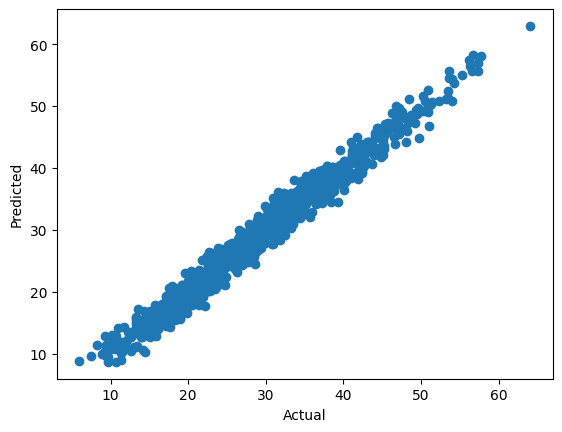

In [21]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

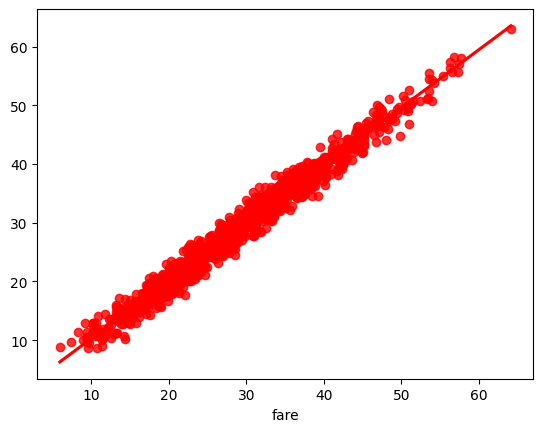

In [22]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

In [23]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
1501,20.84,18.656058,2.183942
2586,36.31,35.546404,0.763596
2653,44.41,42.602488,1.807512
1055,20.72,18.677133,2.042867
705,28.46,30.255920,-1.795920
...,...,...,...
4711,35.40,36.052747,-0.652747
2313,32.54,32.927405,-0.387405
3214,51.26,50.257003,1.002997
2732,42.12,42.637419,-0.517419
